In [13]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v261\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

In [14]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [15]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9

## Specfying the device and solver dimensions and params ##

In [32]:
W_array = np.array([0.5,0.6,0.7,0.9,1.26,1.4,1.4,1.4,1.4,1.31,1.2])*um
#W_array[0] = 0.5*um
L = 2*um
dL = L/12
H = 220*nm
L_rects_device = dL
L_rects_simulation = 5*dL

option = 2
if option == 1:
    L_rects = L_rects_device
else:
    L_rects = L_rects_simulation

x_initial = -(L-dL)/2
y_outputs = (W_array[-1] - W_array[0])/2

#Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

#FDTD:

x_span_fdtd = L + 1.5*L_rects
y_span_fdtd = 2*max(W_array)
z_span_fdtd = 3*H
simulation_time = 20*(L + 2*L_rects)/c

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
number_of_frequency_points = 51
mesh_accuracy = 8

z_min_bc = 'Symmetric'

indxLambda = 24

### Spline interpolation ###

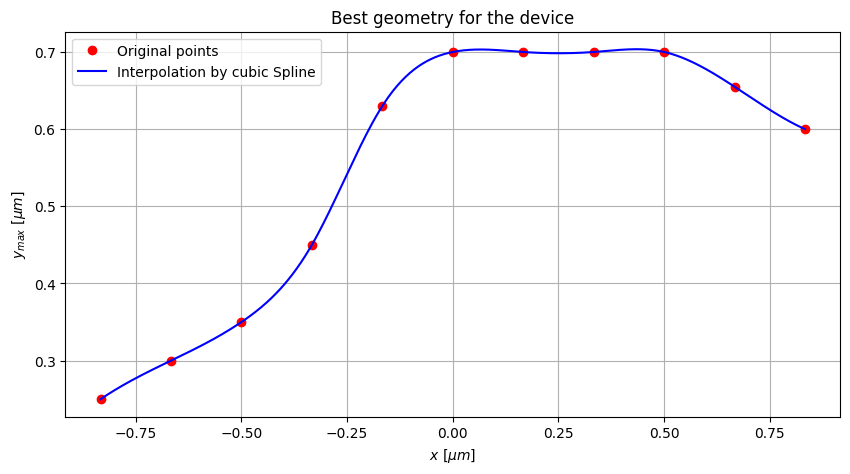

In [33]:
from scipy.interpolate import CubicSpline

y_max_array = W_array/2

x_original = np.arange(-L/2 + dL, L/2-dL, dL)

cs = CubicSpline(x_original, y_max_array)

x_soft = np.linspace(-L/2 + dL, x_original[-1], 500)
y_soft = cs(x_soft)

# 5. Plotando o resultado
plt.figure(figsize=(10, 5))
plt.plot(x_original/um, y_max_array/um, 'o', color='red', label='Original points')
plt.plot(x_soft/um, y_soft/um, '-', color='blue', label='Interpolation by cubic Spline')
plt.title('Best geometry for the device')
plt.xlabel(r'$x\,\,[\mu m]$')
plt.ylabel(r'$y_{max}\,\,[\mu m]$')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
x_original

array([-8.33333333e-07, -6.66666667e-07, -5.00000000e-07, -3.33333333e-07,
       -1.66666667e-07, -2.11758237e-22,  1.66666667e-07,  3.33333333e-07,
        5.00000000e-07,  6.66666667e-07,  8.33333333e-07])

In [18]:
cs = CubicSpline(x_original, y_max_array)

# The variable cs.c is a array with shape (4,len(y_max_array)), where:
# cs.c[0] ->  'a' is an array with the cubic coeficients of the interpolation
# cs.c[1] ->  'b' is an array with the quadratic coeficients of the interpolation
# cs.c[2] ->  'c' is an array with the linear coeficients of the interpolation
# cs.c[3] ->  'd' is an array with the constants of the interpolation
coeficients = cs.c
coeficients[0,:] = coeficients[0,:]*um**2
coeficients[1,:] = coeficients[1,:]*um
coeficients[2,:] = coeficients[2,:]
coeficients[3,:] = coeficients[3,:]/um

print(' '.ljust(24) + 'y\u2098\u2090\u2093=a(x-x\u1D62)³+b(x-x\u1D62)²+c(x-x\u1D62)+d')
print("-" * 80)

print(f"  i |x\u1D62 (\u03BCm) |{'x interval (\u03BCm)':<13} | {'a (\u03BCm/\u03BCm³)':<4} | {'b (\u03BCm/\u03BCm²)':<4} | {'c (\u03BCm/\u03BCm)':<5} |   {'d (\u03BCm)':<5}")
print("-" * 80)

for i in range(0,len(y_max_array)-1,1):
    a = coeficients[0, i]
    b = coeficients[1, i]
    c = coeficients[2, i]
    d = coeficients[3, i]
    print(f" {i} ".ljust(4) + f"|{np.round(x_original[i]/um, 2)}".ljust(9) + f"|[{np.round(x_original[i]/um, 2)},{np.round(x_original[i+1]/um, 2)}]".ljust(16) + f" | {a:>10.4f} | {b:>10.4f} | {c:>9.4f} | {d:>10.4f}")

                        yₘₐₓ=a(x-xᵢ)³+b(x-xᵢ)²+c(x-xᵢ)+d
--------------------------------------------------------------------------------
  i |xᵢ (μm) |x interval (μm) | a (μm/μm³) | b (μm/μm²) | c (μm/μm) |   d (μm)
--------------------------------------------------------------------------------
 0  |-0.83   |[-0.83,-0.67]   |     1.2732 |    -0.6366 |    0.3707 |     0.2500
 1  |-0.67   |[-0.67,-0.5]    |     1.2732 |    -0.0000 |    0.2646 |     0.3000
 2  |-0.5    |[-0.5,-0.33]    |     4.4341 |     0.6366 |    0.3707 |     0.3500
 3  |-0.33   |[-0.33,-0.17]   |   -12.5294 |     2.8536 |    0.9524 |     0.4500
 4  |-0.17   |[-0.17,-0.0]    |     4.6436 |    -3.4111 |    0.8595 |     0.6300
 5  |-0.0    |[-0.0,0.17]     |     2.5950 |    -1.0893 |    0.1095 |     0.7000
 6  |0.17    |[0.17,0.33]     |     0.0966 |     0.2082 |   -0.0374 |     0.7000
 7  |0.33    |[0.33,0.5]      |    -2.9812 |     0.2565 |    0.0401 |     0.7000
 8  |0.5     |[0.5,0.67]      |     2.1082 |    -1.234

## Building the device and solver ##

In [19]:
fdtdApi.addstructuregroup()
fdtdApi.set('name', 'group')

In [ ]:
fdtdApi.addrect()
fdtdApi.set('name', 'poly_0')
fdtdApi.set('material', material)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('x', -L/2 + dL/2)
fdtdApi.set('x span', dL)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W_array[0])
fdtdApi.addtogroup('group')

for i in range(1, len(W_array), 1):
    fdtdApi.addpoly()
    fdtdApi.set('name', 'poly_%d' %i)
    fdtdApi.set('material', material)
    fdtdApi.set('z', 0)
    fdtdApi.set('z span', H)

    xi = (-L/2 + i*dL)/um
    x = np.linspace(xi, xi + dL/um, 100)
    y = coeficients[0,i-1]*(x-xi)**3 + coeficients[1,i-1]*(x-xi)**2 + coeficients[2,i-1]*(x-xi) + coeficients[3,i-1]
    x_block = np.concatenate((x, np.flip(x)))*um
    y_block = np.concatenate((y, -np.flip(y)))*um
    vertices = np.block([[x_block[i], y_block[i]] for i in range(len(x_block))])
    fdtdApi.set('vertices', vertices)
    fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'poly_11')
fdtdApi.set('material', material)
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('x', L/2 - dL/2)
fdtdApi.set('x span', dL)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W_array[-1])
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_1')
fdtdApi.set('x', -L/2 - L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', 0)
fdtdApi.set('y span', W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_2')
fdtdApi.set('x', L/2+ L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', y_outputs)
fdtdApi.set('y span', W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addrect()
fdtdApi.set('name', 'rect_3')
fdtdApi.set('x', L/2+ L_rects/2)
fdtdApi.set('x span', L_rects)
fdtdApi.set('y', -y_outputs)
fdtdApi.set('y span', W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', H)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

In [21]:
fdtdApi.addfdtd()
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)
fdtdApi.set('z span', z_span_fdtd)

fdtdApi.set('background material', sub_material)
fdtdApi.set('global source wavelength start', start_wavelength)
fdtdApi.set('global source wavelength stop', stop_wavelength)
fdtdApi.set('global monitor frequency points', number_of_frequency_points)
fdtdApi.set('Mesh accuracy', mesh_accuracy)
fdtdApi.set('simulation time', simulation_time)
#fdtdApi.set('z min bc', z_min_bc)

# add ports 
fdtdApi.addport()
fdtdApi.set('name', 'port_1')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', -L/2 - L_rects/2)
fdtdApi.set('x span', 0)
fdtdApi.set('y', 0)
fdtdApi.set('y span', 2*W_array[0])
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'port_2')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', L/2 + L_rects/2)
fdtdApi.set('x span', 0)
fdtdApi.set('y', y_outputs)
fdtdApi.set('y span', W_array[-1] - 0.54*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

fdtdApi.addport()
fdtdApi.set('name', 'port_3')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', L/2 + L_rects/2)
fdtdApi.set('x span', 0)
fdtdApi.set('y', -y_outputs)
fdtdApi.set('y span', W_array[-1] - 0.54*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 2*H)

# add monitors

fdtdApi.addindex()
fdtdApi.set('name', 'index')
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xy')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)


In [22]:
if option == 1:
    fdtdApi.save('Compact Y-branch for export')
    fdtdApi.close()
else:
    fdtdApi.save('Compact Y-branch for simulation')

## analyzing the device's behavior  ##

In [23]:
fdtdApi.run()

### Visualizing the device ###

In [24]:
index_x = np.squeeze(fdtdApi.getdata('index', 'index_x').real)
x_device = np.squeeze(fdtdApi.getdata('index', 'x'))/um
y_device = np.squeeze(fdtdApi.getdata('index', 'y'))/um

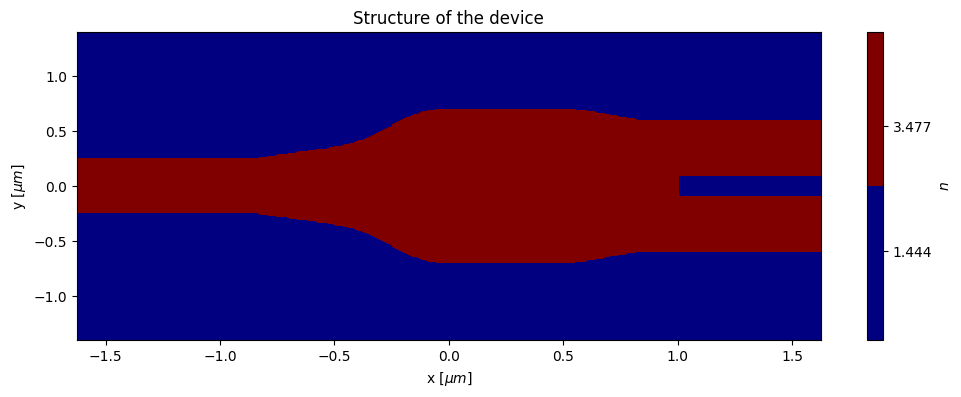

In [25]:
X, Y = np.meshgrid(x_device, y_device)
X, Y = np.transpose(X), np.transpose(Y)
v = np.linspace(np.min(index_x), np.max(index_x), 2)

fig0 = plt.figure(figsize=(12,4))
im0 = plt.contourf(X, Y, index_x, 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im0, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'x [$\mu m$]')
plt.ylabel(r'y [$\mu m$]')
plt.title('Structure of the device')

plt.show()

### Visualizing the eletric field profile ###

In [26]:
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile_xy')))**2

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

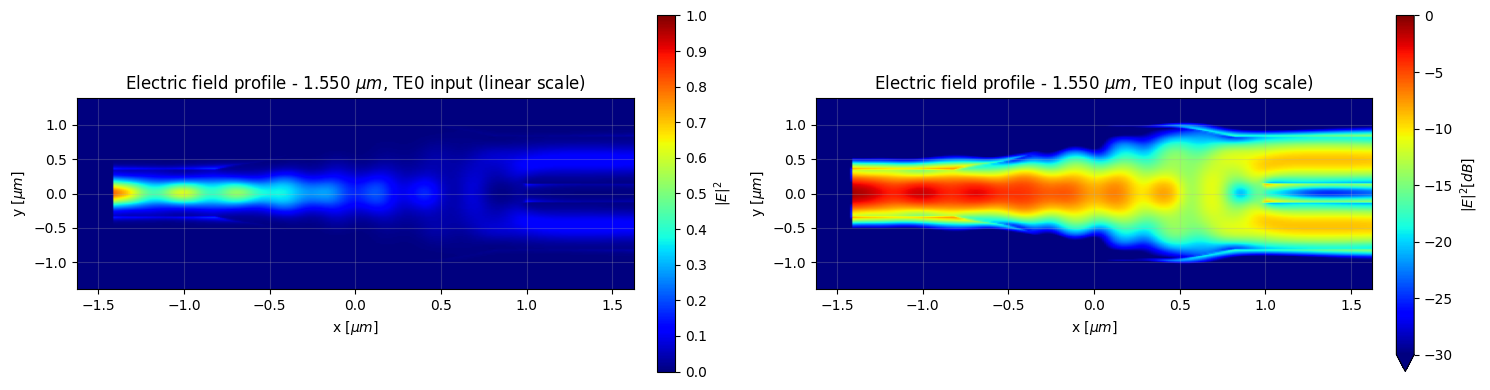

In [27]:
fig1, ax1 = plt.subplots(1,2,figsize=(15,4))
im1 = ax1[0].imshow(np.rot90(eField[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 0.4)
ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im1,fraction = 0.03, pad =0.04, label = r'$|E|^2$', ticks = ticks_linear)

ax1[0].set_xlabel(r'x [$\mu m$]')
ax1[0].set_ylabel(r'y [$\mu m$]')
ax1[0].set_title(r'Electric field profile - %4.3f $\mu m$, TE0 input (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[0].grid(which='major', alpha = 0.25)

im2 = ax1[1].imshow(np.rot90(10*np.log10(eField[:,:,indxLambda])), extent = [xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = 'jet', aspect = 0.4)

colorbar = plt.colorbar(im2, fraction = 0.03, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax1[1].set_xlabel(r'x [$\mu m$]')
ax1[1].set_ylabel(r'y [$\mu m$]')
ax1[1].set_title(r'Electric field profile - %4.3f $\mu m$, TE0 input (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[1].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

### Visualizing the transmission in each port and the insertion loss ###

In [ ]:
ports_1 = np.zeros((3, number_of_frequency_points))
ports_lambda = fdtdApi.getresult('FDTD::ports::port_1', 'T')['lambda']/um

for i in range(1,4,1):
    ports = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    ports_1[i-1, :] = np.abs(ports['T'])

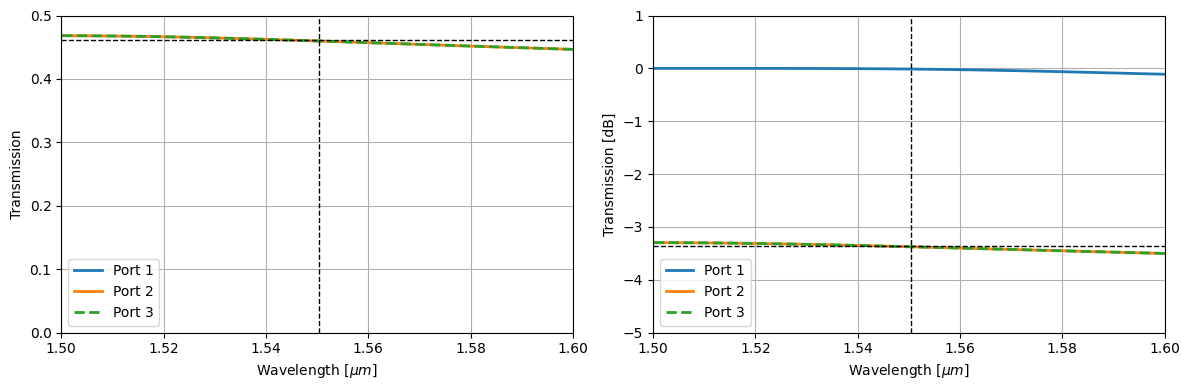

transmission_by_port = -3.36 dB


In [29]:
fig2, ax2 = plt.subplots(1,2,figsize=(12,4))
for i in range(1,4,1):
    linestyle = '-'
    if i == 3:
        linestyle = '--'
    ax2[0].plot(ports_lambda, ports_1[i-1,:]/np.max(ports_1), label = 'Port %d' %i, linewidth = 2, linestyle = linestyle)
    ax2[1].plot(ports_lambda, 10*np.log10(ports_1[i-1,:]/np.max(ports_1)), label = 'Port %d' %i, linewidth = 2, linestyle = linestyle)

ax2[0].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
transmission_by_port = 0.461
ax2[0].axhline(transmission_by_port, color = 'k', linestyle = '--', linewidth = 1)
ax2[0].set_xlabel(r'Wavelength [$\mu m$]')
ax2[0].set_ylabel(r'Transmission')
ax2[0].set_xlim([start_wavelength/um, stop_wavelength/um])
#ax2[0].set_ylim([0,1.1])
ax2[0].set_ylim([0,0.5])
ax2[0].grid(True)
ax2[0].legend(loc = 'best')

ax2[1].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax2[1].axhline(10*np.log10(transmission_by_port), color = 'k', linestyle = '--', linewidth = 1)
ax2[1].set_xlabel(r'Wavelength [$\mu m$]')
ax2[1].set_ylabel(r'Transmission [dB]')
ax2[1].set_xlim([start_wavelength/um, stop_wavelength/um])
ax2[1].set_ylim([-5,1])
ax2[1].grid(True)
ax2[1].legend(loc = 'best')

plt.tight_layout()
plt.show()

print('transmission_by_port = %.2f dB' % (10*np.log10(transmission_by_port)))

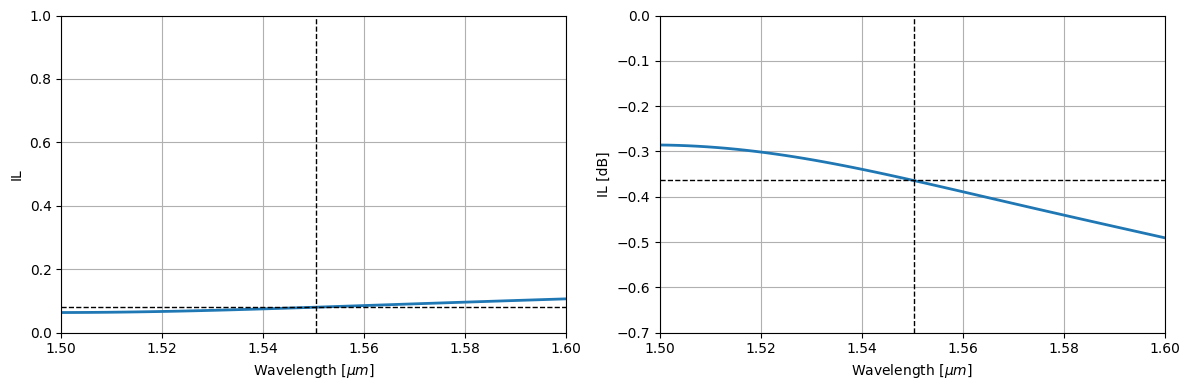

Insertion loss = -0.362 dB


In [30]:
IL = 1-(ports_1[1,:]/np.max(ports_1) + ports_1[2,:]/np.max(ports_1))
IL_dB = 10*np.log10(ports_1[1,:]/np.max(ports_1) + ports_1[2,:]/np.max(ports_1))

fig3, ax3 = plt.subplots(1,2,figsize=(12,4))

ax3[0].plot(ports_lambda, IL, linewidth = 2)
ax3[1].plot(ports_lambda, IL_dB, linewidth = 2)

ax3[0].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
IL_center = 0.08
ax3[0].axhline(IL_center, color = 'k', linestyle = '--', linewidth = 1)
ax3[0].set_xlabel(r'Wavelength [$\mu m$]')
ax3[0].set_ylabel(r'IL')
ax3[0].set_xlim([start_wavelength/um, stop_wavelength/um])
ax3[0].set_ylim([0,1])
ax3[0].grid(True)

ax3[1].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax3[1].axhline(10*np.log10(1-IL_center), color = 'k', linestyle = '--', linewidth = 1)
ax3[1].set_xlabel(r'Wavelength [$\mu m$]')
ax3[1].set_ylabel(r'IL [dB]')
ax3[1].set_xlim([start_wavelength/um, stop_wavelength/um])
ax3[1].set_ylim([-0.7,0])
ax3[1].grid(True)

plt.tight_layout()
plt.show()
print('Insertion loss = %.3f dB' % (10*np.log10(1-IL_center)))

In [31]:
fdtdApi.close()